<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/HW1_Regression_with_inference_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание №1 (base). Часть 1**

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;

**Максимальная оценка за дз**
> Оценка за первую часть домашки = $min(\text{ваш балл}, 7)$


**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.**

Если нет одного и/или другого, то часть баллов за соответствующее задание снимается.

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

random.seed(42)
np.random.seed(42)

Давайте зафиксируем важный момент.

**Задание 0 (0 баллов).**
Изучите и ответье на вопрос: для чего фиксируем сиды в домашках?

`Для воспроизводимости результата`

# **Часть 1 | EDA и визуализация**

Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков (2.5 балла)
- Визуализации признаков и их анализ (1 балл)

Всего можно набрать 3.5 основных балла и 0.65 бонусных. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (2.5 балла)**

In [138]:
import pandas as pd

In [140]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1 (0.5 балла)**

Вы уже встречались с pandas в первой половине семестра. Теперь будем постоянно (кроме некоторых случаев) использовать его для анализа данных и наслаивать навыки. Выполните операции, направленные на практику основных действий с `pandas`:

**0.1 балла**
- [ ] Отобразите 30 случайных строк тренировочного датасета.
- [ ] Отобразите первые 5 и последние 5 объектов тестового датасета
- [ ] Посмотрите, есть ли в датасете пропуски. Запишите/выведите названия колонок, для которых есть пропущенные значения
- [ ] Посмотрите, есть ли в данных явные дубликаты


**0.2 балла**
Ответьте на вопросы:
- [ ] Выводы о чем можно сделать, используя случайные/верхние/нижние строки? А о чем нельзя?
- [ ] Достаточно ли метода duplicated для анализа дубликатов? Почему?

**0.15 балла**
- [ ] Постройте дашборд, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling)

In [141]:
# Отобразите 30 случайных строк тренировочного датасета.
df_train.sample(n=30)

# Отобразите первые 5 и последние 5 объектов тестового датасета
df_train.head(5)
df_train.tail(5)

# Посмотрите, есть ли в датасете пропуски. Запишите/выведите названия колонок, для которых есть пропущенные значения
df_train.columns[df_train.isnull().any()].tolist()

# Посмотрите, есть ли в данных явные дубликаты
print(f'всего число дубликатов {df_train.duplicated().sum()}')

print(f'число численных столбцов {len(df_train.select_dtypes(include=np.number).columns)}')
print(f'число категориальных столбцов {len(df_train.select_dtypes(include=['object', 'category']).columns)}')

всего число дубликатов 985
число численных столбцов 4
число категориальных столбцов 9


##### Выводы о чем можно сделать, используя случайные/верхние/нижние строки? А о чем нельзя?
- сразу можно сказать, что поля 'mileage', 'engine', 'max_power', 'torque', должны подвергнуться обработке, поскольку должны быть численными признаками;

In [142]:
# Постройте дашборд, используя ydata-profilling
# использовал другой дашборд
import sweetviz as sv

# Анализ данных
report = sv.analyze(df_train)
report.show_html('sweetviz_report.html')

# к сожалению ydata-profilling конфликтовал с моим python, легче было посмотреть на аналог - sweetviz

                                             |                                                    | [  0%]   0…

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Мы обнаружили пропуски. Давайте избавимся от них.

**(0.05 балла)**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось. Заполнение пропусков проводите для обоих наборов данных, если необходимо

**Важно!**

При заполнении пропусков и в тестовом, и тренировочном наборах данных вы определяетесь со стратегией предобработки пропущенных значений при потенциальной работе модели.

Так как в теоретическом случае вы не имеете доступа к тестовой выборке, то заполняемой значение (у нас — медиана) вы считаете про *тренировочному* набору данных и им же заполняете *тестовый*.

In [143]:
# Заполните пропуски в столбцах медианами.
# Убедитесь, что после заполнения пропусков не осталось. Заполнение пропусков проводите для обоих наборов данных, если необходимо
import re

print(f'число численных столбцов после обработки {len(df_train.select_dtypes(include=np.number).columns)}')
print(f'число категориальных столбцов после обработки {len(df_train.select_dtypes(include=['object', 'category']).columns)}')

def extract_number(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    match = re.search(r'(\d+\.?\d*)', str(value))
    return float(match.group(1)) if match else np.nan

# ---------- Очищаем и заполняем ----------
columns_to_clean = ['mileage', 'engine', 'max_power', 'torque', 'seats']

def changeCatForReal(data, columns):
    for col in columns_to_clean:
        # Извлекаем числа во временную колонку
        data[col + '_clean'] = data[col].apply(extract_number)
    
        # Вычисляем медиану
        median_val = data[col + '_clean'].median()
    
        # Заполняем пропуски (БЕЗ inplace=True)
        data[col + '_clean'] = data[col + '_clean'].fillna(median_val)
    
        # Заменяем исходную колонку
        data[col] = data[col + '_clean']
    
        # Удаляем временную колонку
        data.drop(columns=[col + '_clean'], inplace=True)

changeCatForReal(df_train, columns_to_clean)    

# ---------- Проверка ----------
print("=== ПОСЛЕ очистки и заполнения ===")
print(df_train[columns_to_clean].head(10))
print("\nПроверка пропусков:")
print(df_train[columns_to_clean].isnull().sum())
print(f"\nВсего пропусков: {df_train[columns_to_clean].isnull().sum().sum()}")
print("Train data shape:", df_train.shape)

print(f'число численных столбцов после обработки {len(df_train.select_dtypes(include=np.number).columns)}')
print(f'число категориальных столбцов после обработки {len(df_train.select_dtypes(include=['object', 'category']).columns)}')

число численных столбцов после обработки 4
число категориальных столбцов после обработки 9
=== ПОСЛЕ очистки и заполнения ===
   mileage  engine  max_power  torque  seats
0    23.40  1248.0      74.00  190.00    5.0
1    21.14  1498.0     103.52  250.00    5.0
2    23.00  1396.0      90.00   22.40    5.0
3    16.10  1298.0      88.20   11.50    5.0
4    20.14  1197.0      81.86  113.75    5.0
5    17.30  1061.0      57.50    7.80    5.0
6    16.10   796.0      37.00   59.00    4.0
7    23.59  1364.0      67.10  170.00    5.0
8    20.00  1399.0      68.10  160.00    5.0
9    19.01  1461.0     108.45  248.00    5.0

Проверка пропусков:
mileage      0
engine       0
max_power    0
torque       0
seats        0
dtype: int64

Всего пропусков: 0
Train data shape: (6999, 13)
число численных столбцов после обработки 8
число категориальных столбцов после обработки 5


### **Задание 2 (0.5 балла)**

На прошлом шаге вы рассмотрели дубликаты. Однако дубликат может быть связан с не только полным повторением информации в нескольких строках, но и частиным. Например, объект мог был внесен в базу данных с разным значением целевой переменной. В этом шаге займемся такими дублями!

**Ваши действия:**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.1 балла)
- [ ] Отобразите такие объекты (0.15 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.15 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.1 балла)


In [144]:
#1. Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.1 балла)
#2.  Отобразите такие объекты (0.15 балла)
feature_columns = [col for col in df_train.columns if col != 'selling_price']
print(f"Колонки-признаки ({len(feature_columns)}): {feature_columns}")
duplicate_mask = df_train.duplicated(subset=feature_columns, keep=False)
duplicate_rows_total = duplicate_mask.sum()
duplicate_rows_repeated = df_train.duplicated(subset=feature_columns, keep='first').sum()
print(f'всего строк с дубликатами {duplicate_rows_total}')
print(f'всего повторяющихся строк {duplicate_rows_repeated}')
unique_groups = duplicate_rows_total - duplicate_rows_repeated
print(f'число уникальных строк {unique_groups}')
#3.  Удалите повторяющиеся строки.
# Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.15 балла)
df_train_cleaned = df_train.drop_duplicates(subset=feature_columns, keep='first')
print(f"Удалено строк: {len(df_train) - len(df_train_cleaned)}")
print(f"Осталось строк: {len(df_train_cleaned)}")
assert df_train_cleaned.duplicated(subset=feature_columns).sum() == 0, "Остались дубликаты!"

# Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.1 балла)
print(df_train_cleaned.shape)
df_train_cleaned = df_train_cleaned.reset_index(drop=True)
print(df_train_cleaned.shape)

Колонки-признаки (12): ['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']
всего строк с дубликатами 1799
всего повторяющихся строк 1159
число уникальных строк 640
Удалено строк: 1159
Осталось строк: 5840
(5840, 13)
(5840, 13)


Отлично! Мы избавились от маленьких и явных проблем. Теперь перейдем к более сложным недостаткам полученной таблицы.

### **Задание 3 (0.25 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными — они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Удалите столбец ``torque``


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.
- Стобец ``torque`` мы удаляем для простоты. В идеальном случае, его также стоило бы предобработать.

In [145]:
# Поскольку я уже делал это для train выборки , то проделаю и для test

# ---------- Очищаем и заполняем ----------
columns_to_clean = ['mileage', 'engine', 'max_power', 'torque', 'seats']

for col in columns_to_clean:
    # Извлекаем числа во временную колонку
    df_test[col + '_clean'] = df_test[col].apply(extract_number)
    
    # Вычисляем медиану
    median_val = df_test[col + '_clean'].median()
    
    # Заполняем пропуски (БЕЗ inplace=True)
    df_test[col + '_clean'] = df_test[col + '_clean'].fillna(median_val)
    
    # Заменяем исходную колонку
    df_test[col] = df_test[col + '_clean']
    
    # Удаляем временную колонку
    df_test.drop(columns=[col + '_clean'], inplace=True)

# ---------- Проверка ----------
print("=== ПОСЛЕ очистки и заполнения ===")
print(df_test[columns_to_clean].head(10))
print("\nПроверка пропусков:")
print(df_test[columns_to_clean].isnull().sum())
print(f"\nВсего пропусков: {df_test[columns_to_clean].isnull().sum().sum()}")
print("Train data shape:", df_test.shape)

df_train_cleaned['mileage'] = pd.to_numeric(df_train_cleaned['mileage'], errors='raise')
df_train_cleaned['engine'] = pd.to_numeric(df_train_cleaned['engine'], errors='raise')
df_train_cleaned['max_power'] = pd.to_numeric(df_train_cleaned['max_power'], errors='raise')
df_train_cleaned.drop('torque', axis=1, inplace=True)

df_test['mileage'] = pd.to_numeric(df_test['mileage'], errors='raise')
df_test['engine'] = pd.to_numeric(df_test['engine'], errors='raise')
df_test['max_power'] = pd.to_numeric(df_test['max_power'], errors='raise')
df_test.drop('torque', axis=1, inplace=True)

print(f'число численных столбцов после обработки {len(df_test.select_dtypes(include=np.number).columns)}')
print(f'число категориальных столбцов после обработки {len(df_test.select_dtypes(include=['object', 'category']).columns)}')

=== ПОСЛЕ очистки и заполнения ===
   mileage  engine  max_power  torque  seats
0    14.00  2498.0      112.0   260.0    7.0
1    21.50  1497.0      108.5   260.0    5.0
2    12.90  1799.0      130.0   172.0    5.0
3    25.10  1498.0       98.6   200.0    5.0
4    16.50  1172.0       65.0    96.0    5.0
5    16.55  2498.0      105.0   247.0    6.0
6    18.00   995.0       62.0    90.3    5.0
7    18.50  1197.0       85.8   114.0    5.0
8    19.70   796.0       46.3    62.0    5.0
9    19.67  1582.0      126.2   259.9    5.0

Проверка пропусков:
mileage      0
engine       0
max_power    0
torque       0
seats        0
dtype: int64

Всего пропусков: 0
Train data shape: (1000, 13)
число численных столбцов после обработки 7
число категориальных столбцов после обработки 5


### **Задание 4 (0.1 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.

In [146]:
df_test['engine'] = df_test['engine'].astype(int)
df_test['seats'] = df_test['seats'].astype(int)

df_train_cleaned['engine'] = df_train_cleaned['engine'].astype(int)
df_train_cleaned['seats'] = df_train_cleaned['seats'].astype(int)


### **Задание 5 (0.15 балла)**

Отлично! Мы провели "косметическую" предобработку и теперь готовы сделать важный шаг в контексте анализа данных. А именно — посмотреть на статистики!

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сделайте вывод.

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

**Примечание:**

Более корректно рассматривать статистики до заполнения пропусков и после, чтобы убедиться, что мы не внесли каких-либо серьезных сдвигов в изначальные рапсределения.

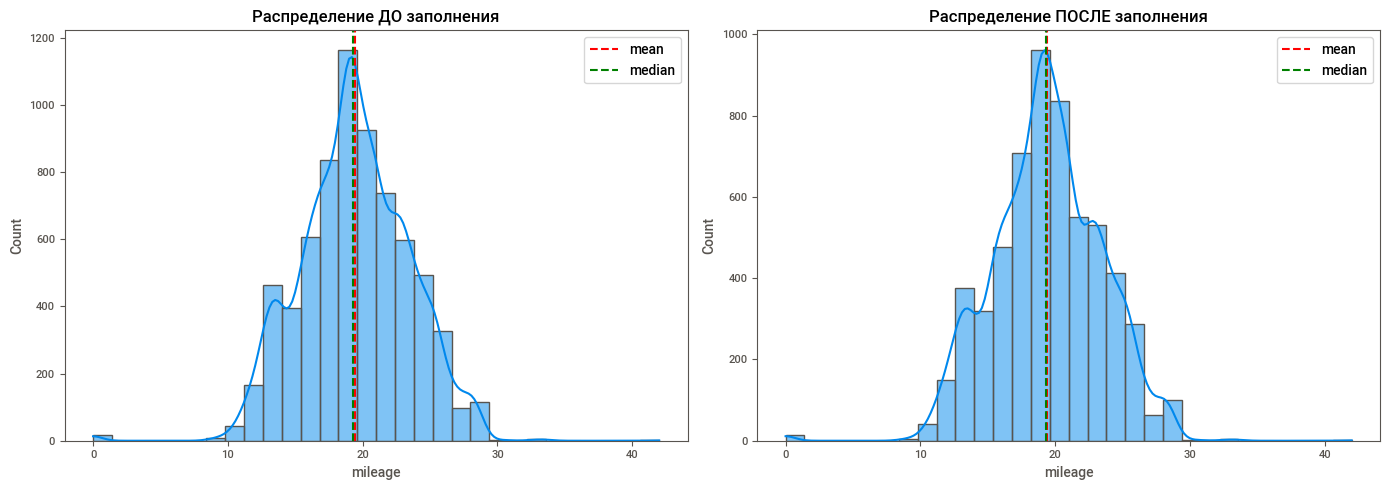

 уникальные данные До преобразования name             1924
year               29
selling_price     637
km_driven         827
fuel                4
seller_type         3
transmission        2
owner               5
mileage           375
engine            120
max_power         313
torque            234
seats               9
dtype: int64
 уникальные данные ПОСЛЕ преобразования name             1924
year               29
selling_price     629
km_driven         827
fuel                4
seller_type         3
transmission        2
owner               5
mileage           375
engine            120
max_power         313
seats               9
dtype: int64


In [147]:
# анализ статистики до преобразования 

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ДО
sns.histplot(df_train['mileage'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Распределение ДО заполнения')
axes[0].axvline(df_train['mileage'].mean(), color='red', linestyle='--', label='mean')
axes[0].axvline(df_train['mileage'].median(), color='green', linestyle='--', label='median')
axes[0].legend()

# ПОСЛЕ
sns.histplot(df_train_cleaned['mileage'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Распределение ПОСЛЕ заполнения')
axes[1].axvline(df_train_cleaned['mileage'].mean(), color='red', linestyle='--', label='mean')
axes[1].axvline(df_train_cleaned['mileage'].median(), color='green', linestyle='--', label='median')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f' уникальные данные До преобразования {df_train.nunique()}')
print(f' уникальные данные ПОСЛЕ преобразования {df_train_cleaned.nunique()}')

In [148]:
numeric_cols = df_train_cleaned.select_dtypes(include=np.number).columns

df_train_cleaned.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine             int64
max_power        float64
seats              int64
dtype: object

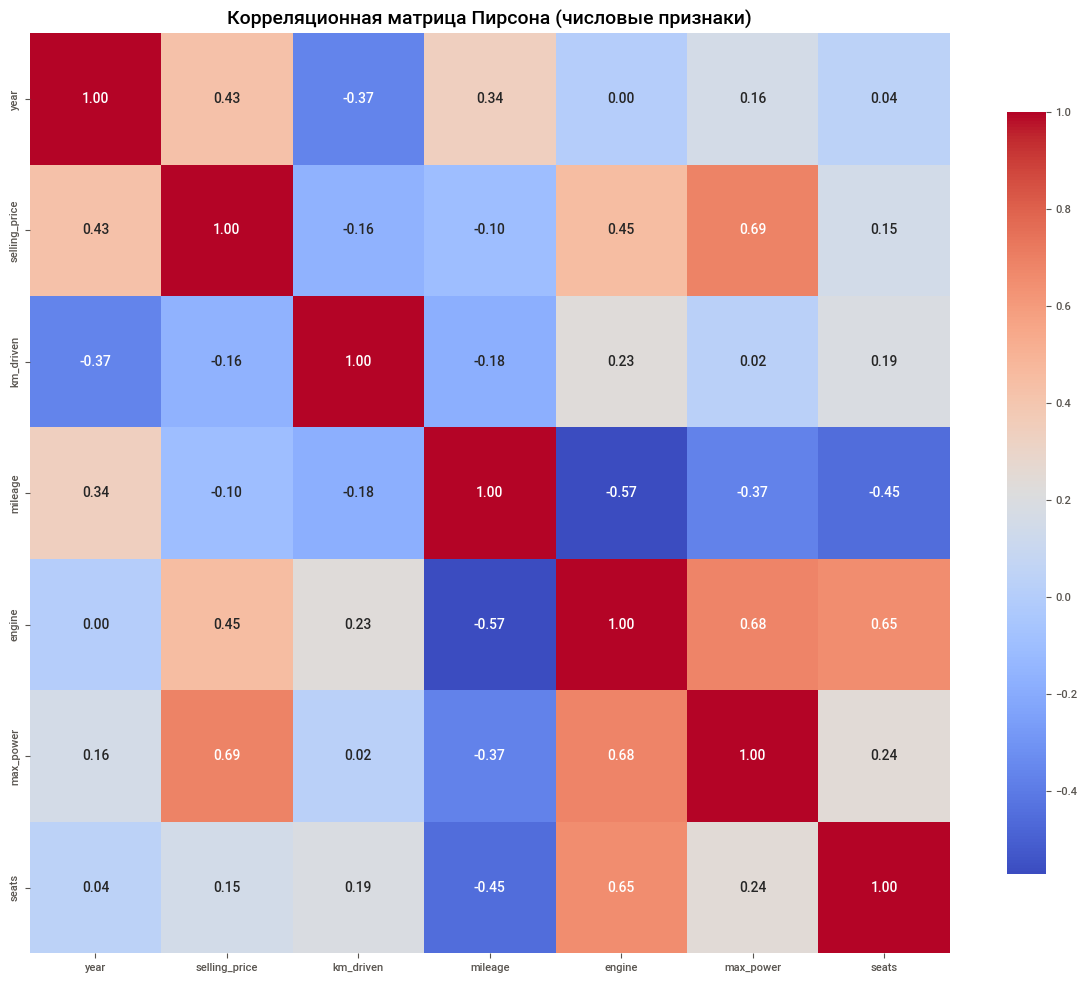

In [149]:

plt.figure(figsize=(12, 10))

sns.heatmap(
    df_train_cleaned[numeric_cols].corr(),   # корреляция только по числовым
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Корреляционная матрица Пирсона (числовые признаки)', fontsize=14)
plt.tight_layout()
plt.show()

In [150]:
df_train.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats
count,6999.000000,6.999000e+03,6.999000e+03,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000
mean,2013.818403,6.395152e+05,6.958462e+04,19.422950,1452.256894,91.232627,168.161019,5.406915
std,4.053095,8.089419e+05,5.772400e+04,3.986931,495.151300,35.348760,95.952684,0.954308
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,4.800000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.800000,1197.000000,68.050000,104.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,82.000000,160.000000,5.000000
75%,2017.000000,6.750000e+05,9.700000e+04,22.150000,1582.000000,100.600000,200.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,789.000000,14.000000


In [151]:
df_train_cleaned.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.428611,1429.448973,87.910782,5.426712
std,4.095622,5.354320e+05,6.007114e+04,3.986026,485.662834,31.639585,0.982344
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.000000,68.000000,5.000000
50%,2014.000000,4.050000e+05,7.000000e+04,19.300000,1248.000000,81.860000,5.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


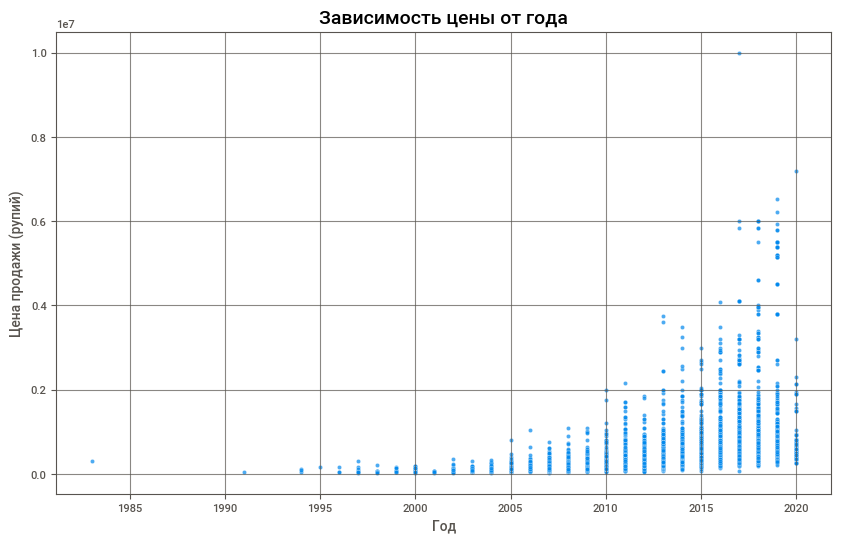

In [152]:
# Предположим, что ваш DataFrame называется df
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='year', y='selling_price', alpha=0.7)

plt.title('Зависимость цены от года', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Цена продажи (рупий)')
plt.grid(True, alpha=0.7)
plt.savefig(r"C:\Users\akhme\Documents\relation_selling_price.png")
plt.show()


## **Визуализации (1 балл + 0.5 бонус)**



Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 6 (0.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

Числовые колонки: ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']


<Figure size 1200x1000 with 0 Axes>

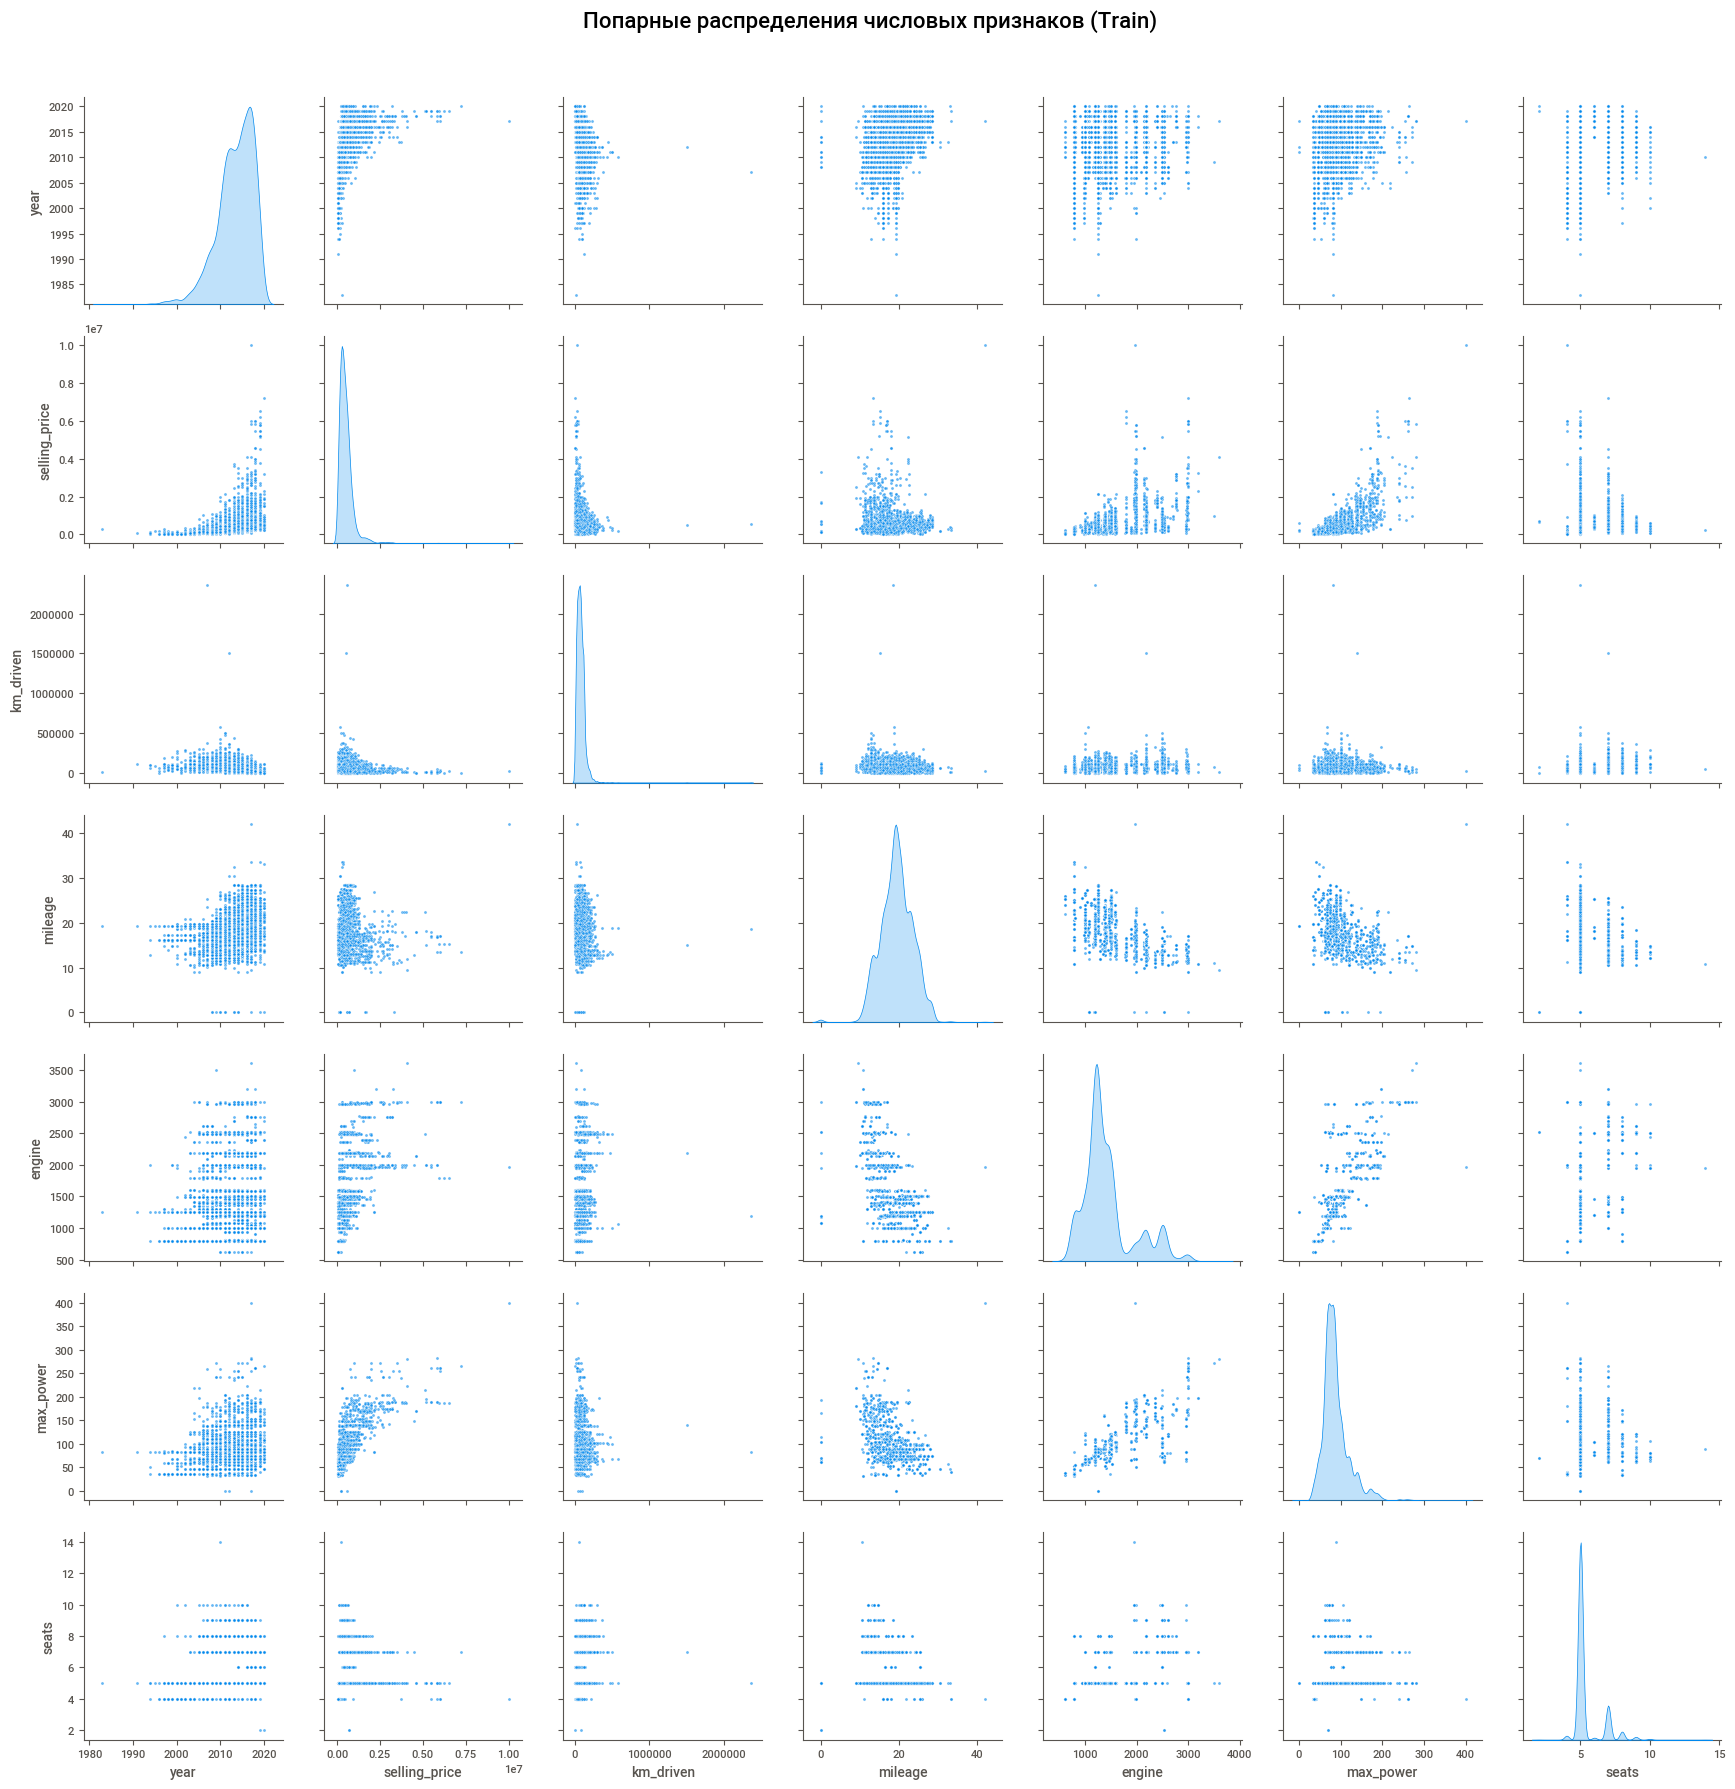

In [153]:
numeric_cols = df_train_cleaned.select_dtypes(include=np.number).columns.tolist()
print(f"Числовые колонки: {numeric_cols}")
plt.figure(figsize=(12, 10))

# Базовый pairplot
pairplot = sns.pairplot(
    df_train_cleaned[numeric_cols],
    diag_kind='kde',           # На диагонали - графики плотности (вместо гистограмм)
    kind='scatter',            # На остальных - scatter plots
    markers='.',               # Размер точек
    height=2.5,                # Размер каждого графика
    corner=False,              # Показываем все графики (не только нижний треугольник)
    plot_kws={'alpha': 0.6, 's': 20},  # Прозрачность и размер точек
    diag_kws={'fill': True, 'linewidth': 0.5}  # Настройка диагональных графиков
)

pairplot.fig.suptitle('Попарные распределения числовых признаков (Train)', y=1.02, fontsize=16)

# Показываем
plt.tight_layout()
plt.show()

In [154]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# Очищаем данные
df_train_cleaned = df_train_cleaned.dropna(subset=['engine', 'selling_price'])

# Берем выборку для скорости (если данных много)
sample = df_train_cleaned.sample(min(5000, len(df_train_cleaned)), random_state=42)

# Строим scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(data=sample, x='engine', y='selling_price', alpha=0.3, s=10, color='blue')

# Добавляем LOWESS (сглаживание)
lowess_result = lowess(sample['selling_price'], sample['engine'], frac=0.3)
plt.plot(lowess_result[:, 0], lowess_result[:, 1], color='red', linewidth=3, label='LOWESS (сглаживание)')

# Добавляем линейную регрессию для сравнения
sns.regplot(data=sample, x='engine', y='selling_price', scatter=False, 
            color='green', line_kws={'linewidth': 2, 'linestyle': '--'}, label='Линейная регрессия')

plt.title('Проверка линейности: LOWESS vs Линейная регрессия', fontsize=14)
plt.xlabel('Объем двигателя (куб. см)')
plt.ylabel('Цена (рупий)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


NameError: name 'df_clean' is not defined

In [ ]:
numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

# Рисуем boxplot для всех признаков (горизонтально)
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_train[numeric_features], orient='h', flierprops=dict(marker='o', markersize=3))
plt.title('Boxplot для всех числовых признаков (train)', fontsize=14)
plt.xlabel('Значение')
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()

##### ответ на Шаг1
##### Глядя на рисунок, и тепловую карту можнно сказать:
- что больше коррелируют между собой технические характеристики машин, что логично, поскольку они входят в формулу расчета мощности (max_power, torque, engine);
- остальные данные согласуются с ценой, чем старше авто, тем оно дешевле, диапазон цен расположен посреди всего диапазона engine И т.д.
##### ответ на шаг2

In [ ]:
df_test.dtypes
df_test.select_dtypes(include=['object', 'category']).columns
df_test.select_dtypes(include=np.number).columns

In [ ]:
numeric_cols = df_test.select_dtypes(include=np.number).columns.tolist()
print(f"Числовые колонки: {numeric_cols}")
plt.figure(figsize=(12, 10))

# Базовый pairplot
pairplot = sns.pairplot(
    df_test[numeric_cols],
    diag_kind='kde',           # На диагонали - графики плотности (вместо гистограмм)
    kind='scatter',            # На остальных - scatter plots
    markers='.',               # Размер точек
    height=2.5,                # Размер каждого графика
    corner=False,              # Показываем все графики (не только нижний треугольник)
    plot_kws={'alpha': 0.6, 's': 20},  # Прозрачность и размер точек
    diag_kws={'fill': True, 'linewidth': 0.5}  # Настройка диагональных графиков
)

pairplot.fig.suptitle('Попарные распределения числовых признаков (Train)', y=1.02, fontsize=16)

# Показываем
plt.tight_layout()
plt.show()

In [ ]:
numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

# Рисуем boxplot для всех признаков (горизонтально)
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_test[numeric_features], orient='h', flierprops=dict(marker='o', markersize=3))
plt.title('Boxplot для всех числовых признаков (train)', fontsize=14)
plt.xlabel('Значение')
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()

`Да, данные оказались похожими на тренировочную выборку. С более разреженной картиной`

### **Задание 7 (0.5 балла)**

И так, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)


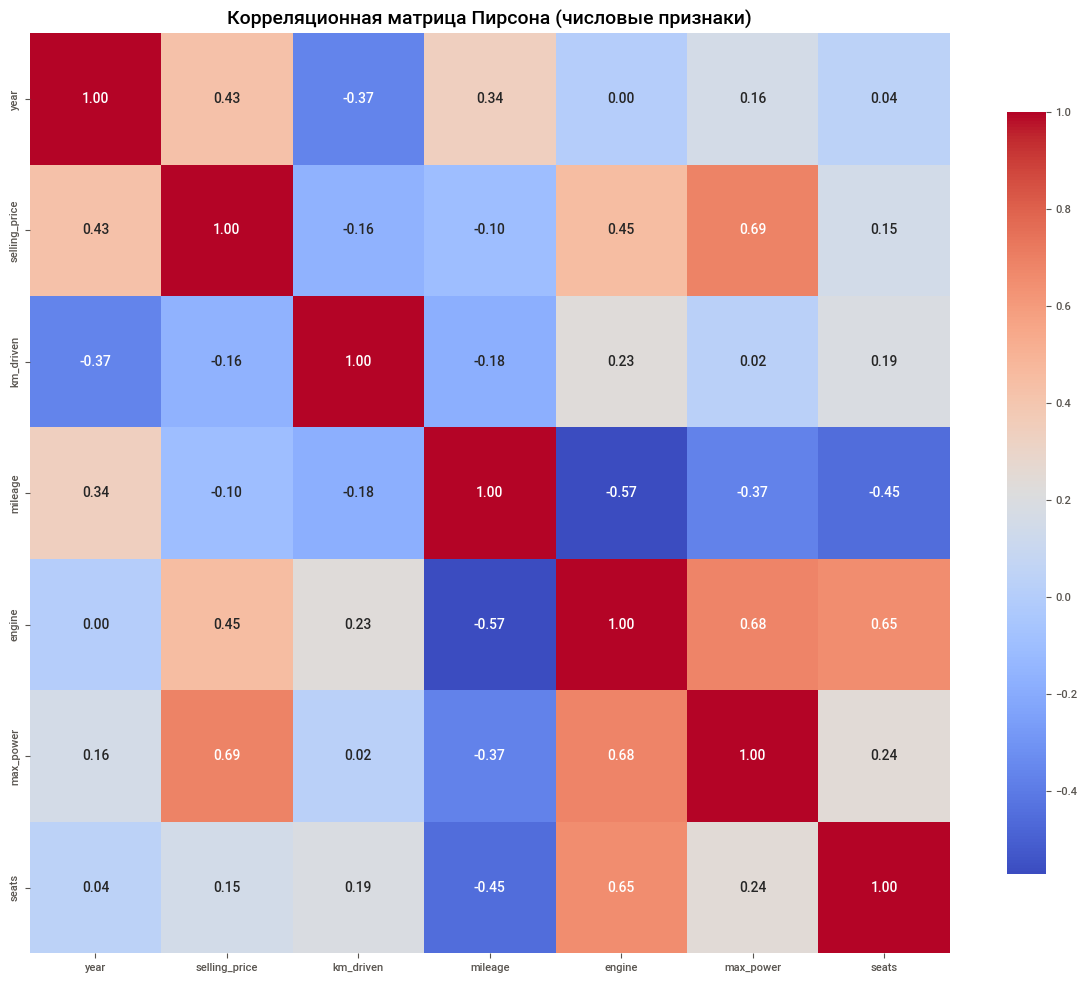

In [155]:
numeric_cols = df_train_cleaned.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 10))

sns.heatmap(
    df_train_cleaned[numeric_cols].corr(),   # корреляция только по числовым
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Корреляционная матрица Пирсона (числовые признаки)', fontsize=14)
plt.tight_layout()
plt.show()

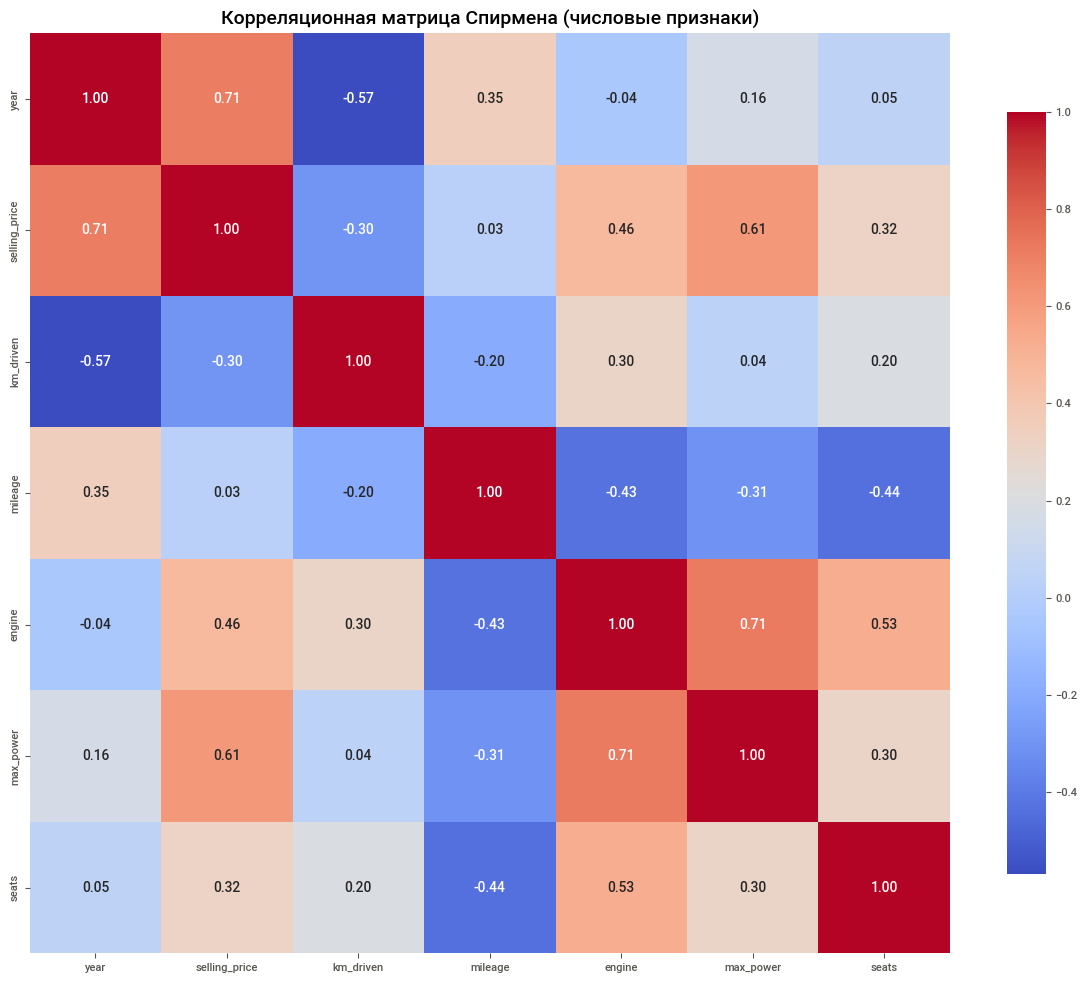

In [156]:
numeric_cols = df_train_cleaned.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 10))

sns.heatmap(
    df_train_cleaned[numeric_cols].corr(method='spearman'),   # корреляция только по числовым
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Корреляционная матрица Спирмена (числовые признаки)', fontsize=14)
plt.tight_layout()
plt.show()

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

`Your answer here`
- наименне коррелированы между собой year и engine.
- между признаками, с которыми производится расчет технических характеристик двигателя - max_power, engine, torque
- да, чем меньше год, тем больше километров, это видно по тепловой карте, обратная корреляция.
- есть выбросы для km_driven  и для target переменной, от которых наверное следует избавиться.

### **Бонус (0.5 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их **и поясните.**

- Каждая дополнительная визуализация может принести до 0.25 баллов при условии, что она обоснована.

##### нарисовал на предыдущих графиках

# **Часть 2 | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.25 балла;

### **Задание 8 (0.05 балла)**

Сделайте тренировочный и тестовый наборы. Сделайте на тренировочный и тестовый наборы. Она уже даны, достаточно просто отделить целевой признак Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных. Используйте уже имеющиеся данные train и test при разбиении. Если считаете уместным применить какую-то более хитрую технику разбиения — примените, но опишите, зачем.

In [157]:
df_train = df_train_cleaned.copy()
df_test = df_test.copy()
cat_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
y_train = df_train['selling_price']
y_test = df_test['selling_price']

print(f'sow cat_cols before: {cat_cols}')
if 'selling_price' not in cat_cols:
    cat_cols.append('selling_price')
    
print(f'sow cat_cols after: {cat_cols}')
df_train.drop(cat_cols, axis=1, inplace=True)
df_test.drop(cat_cols, axis=1, inplace=True)

sow cat_cols before: ['name', 'fuel', 'seller_type', 'transmission', 'owner']
sow cat_cols after: ['name', 'fuel', 'seller_type', 'transmission', 'owner', 'selling_price']


In [158]:

X_train = df_train
X_test = df_test

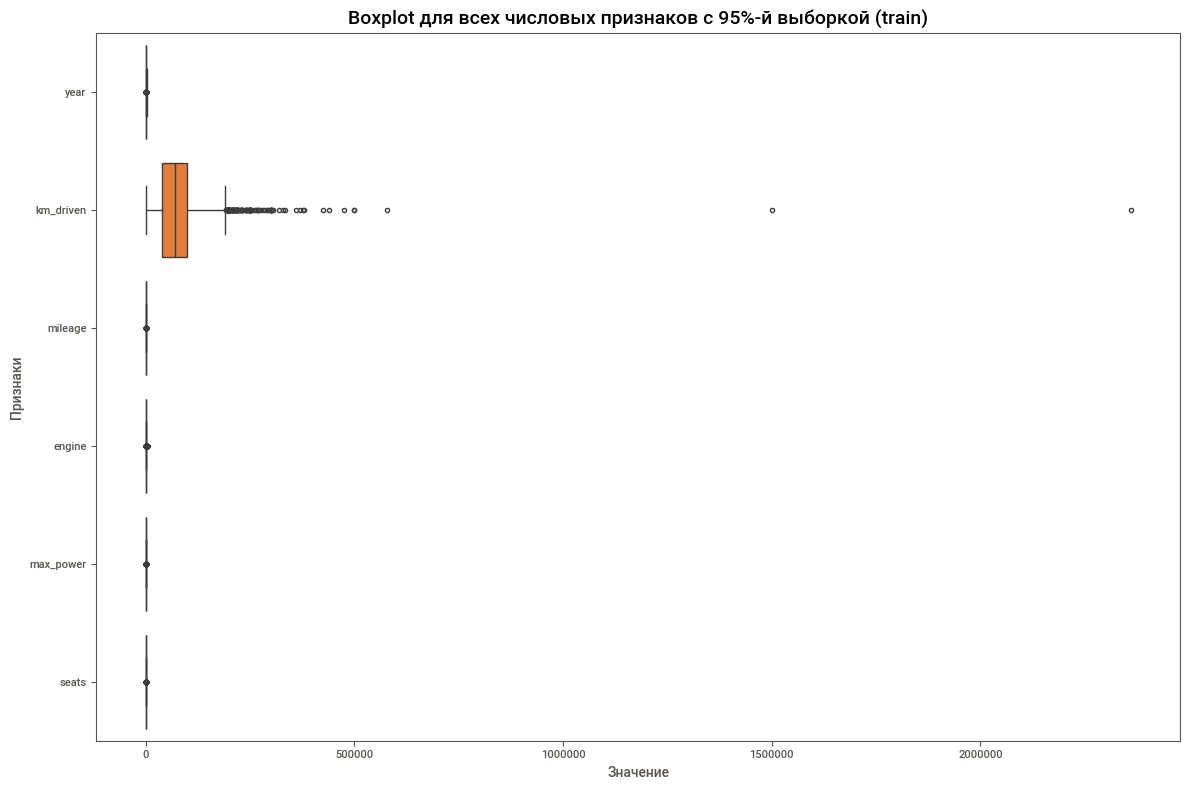

In [159]:

# Рисуем boxplot для всех признаков (горизонтально)
plt.figure(figsize=(12, 8))
sns.boxplot(data=X_train, orient='h', flierprops=dict(marker='o', markersize=3))
plt.title('Boxplot для всех числовых признаков с 95%-й выборкой (train)', fontsize=14)
plt.xlabel('Значение')
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()

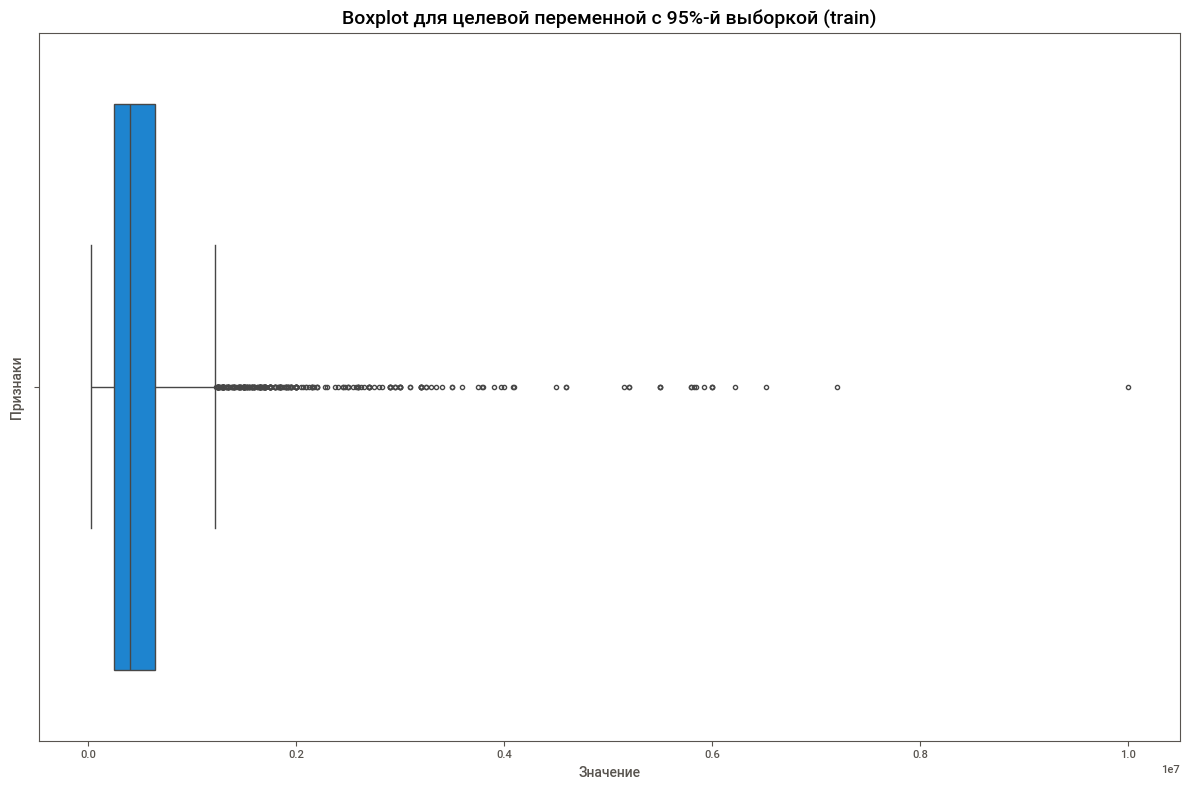

In [160]:

# Рисуем boxplot для всех признаков (горизонтально)
plt.figure(figsize=(12, 8))
sns.boxplot(data=y_train, orient='h', flierprops=dict(marker='o', markersize=3))
plt.title('Boxplot для целевой переменной с 95%-й выборкой (train)', fontsize=14)
plt.xlabel('Значение')
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()

### **Задание 9 (0.2 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [161]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE, mean_absolute_error as MAE


model = LinearRegression()

model.fit(X_train, y_train)
y_predict = model.predict(X_test)
y_predict

array([ 6.29873319e+05,  9.35857004e+05,  6.15744384e+05,  6.77550189e+05,
        1.57988172e+05,  1.05063520e+06,  1.41638815e+05,  4.25116647e+05,
       -5.85308012e+04,  1.05236048e+06,  1.15044439e+06,  2.22726700e+06,
        8.66395117e+05,  2.26784329e+05,  7.38458400e+05,  2.87026905e+06,
        5.70419556e+05,  2.12092898e+05,  4.35486374e+05,  5.16208166e+05,
        3.05601291e+05,  5.73755458e+04,  1.00327872e+06,  5.68475057e+04,
        5.91502583e+05,  7.40130073e+05,  1.11973743e+06,  1.09699225e+06,
        3.75924554e+05,  6.41442139e+05,  1.07512508e+06,  8.98716792e+05,
        5.91731264e+05,  6.29004416e+05,  3.51188450e+05,  4.31386714e+05,
        5.36852128e+05,  3.23890665e+05,  5.62731606e+05,  8.18543401e+05,
        2.93857133e+05,  3.77296450e+05,  3.38177728e+05,  3.64164676e+05,
        3.33747094e+05,  2.36962829e+05,  2.28750697e+05,  2.75866097e+05,
        5.33175113e+05,  7.71817266e+05,  1.63965438e+05,  2.73115951e+05,
        6.73496286e+05,  

In [163]:
model.coef_

array([ 3.73218896e+04, -7.34992383e-01,  7.22111445e+03,  1.25976483e+02,
        1.02026416e+04, -2.36399466e+04])

In [164]:
r2m = r2_score(y_test, y_predict)
print(f' оценка согласно r2: {r2m}')
mse = MSE(y_test, y_predict)
print(f' оценка согласно MSE: {mse}')
print(f' оценка согласно RMSE: {np.sqrt(r2m)}')
mae = MAE(y_test, y_predict)
print(f' оценка согласно MAE: {mae}')

 оценка согласно r2: 0.59414385195975
 оценка согласно MSE: 233297703374.95956
 оценка согласно RMSE: 0.7708072729027341
 оценка согласно MAE: 224473.0235604038


### **Задание 10 (0.15 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

In [165]:
y_train.describe()

count    5.840000e+03
mean     5.229601e+05
std      5.354320e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.050000e+05
75%      6.400000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

In [166]:
from sklearn.preprocessing import StandardScaler
model2 = LinearRegression()
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2.fit(X_train_scaled, y_train)
y_predict  = model2.predict(X_test_scaled)



In [167]:
X_train_scaled

array([[ 0.13956959,  1.19115249,  0.99641312, -0.37364298, -0.4397015 ,
        -0.43441899],
       [ 0.13956959,  0.76661943,  0.42938385,  0.14116151,  0.49338685,
        -0.43441899],
       [-0.83716668,  0.88315792,  0.89605396, -0.06887872,  0.06603744,
        -0.43441899],
       ...,
       [-0.10461448,  0.60013588, -0.23298663, -0.4786631 , -0.15996465,
        -0.43441899],
       [-1.56971888,  0.74997108, -0.65951308,  0.13086542,  0.69821112,
        -0.43441899],
       [-1.08135075,  0.76661943, -0.03226831, -0.37364298, -0.44286237,
        -0.43441899]], shape=(5840, 6))

In [168]:
r2m = r2_score(y_test, y_predict)
print(f' оценка согласно r2: {r2m}')
mse = MSE(y_test, y_predict)
print(f' оценка согласно MSE: {mse}')
print(f' оценка согласно RMSE: {np.sqrt(r2m)}')
mae = MAE(y_test, y_predict)
print(f' оценка согласно MAE: {mae}')

 оценка согласно r2: 0.5941438519597676
 оценка согласно MSE: 233297703374.94943
 оценка согласно RMSE: 0.7708072729027455
 оценка согласно MAE: 224473.02356040676


### **Задание 11 (0.1 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [172]:
# Получаем коэффициенты модели
coefficients = model.coef_
intercept = model.intercept_

# Создаем DataFrame для удобного просмотра
feature_names = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients,
    '|Коэффициент|': np.abs(coefficients)
}).sort_values('|Коэффициент|', ascending=False)

print("="*60)
print("КОЭФФИЦИЕНТЫ МОДЕЛИ")
print("="*60)
print(f"Свободный член (intercept): {intercept:,.2f} руб.")
print("\nКоэффициенты признаков:")
print(feature_importance.to_string(index=False))
print("="*60)

# Интерпретация
print("\nИНТЕРПРЕТАЦИЯ:")
for _, row in feature_importance.iterrows():

    print(f"{row['Признак']:12s}: при увеличении на 1 std, "
          f"цена меняется на {row['Коэффициент']:,.0f} руб.")

КОЭФФИЦИЕНТЫ МОДЕЛИ
Свободный член (intercept): -75,656,647.08 руб.

Коэффициенты признаков:
  Признак   Коэффициент  |Коэффициент|
     year  37321.889568   37321.889568
    seats -23639.946620   23639.946620
max_power  10202.641566   10202.641566
  mileage   7221.114448    7221.114448
   engine    125.976483     125.976483
km_driven     -0.734992       0.734992

ИНТЕРПРЕТАЦИЯ:
year        : при увеличении на 1 std, цена меняется на 37,322 руб.
seats       : при увеличении на 1 std, цена меняется на -23,640 руб.
max_power   : при увеличении на 1 std, цена меняется на 10,203 руб.
mileage     : при увеличении на 1 std, цена меняется на 7,221 руб.
engine      : при увеличении на 1 std, цена меняется на 126 руб.
km_driven   : при увеличении на 1 std, цена меняется на -1 руб.


###### Наиболее информативным оказались два признака, max_power и km_driven при изменении на 1 std 

### **Задание 12 (0.25 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

##### Разделим X_train y_train на тренировочную и валидационную выборки

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
scalerVal = StandardScaler()

X_train2, X_val, y_train2, y_val = train_test_split(X_train, y_train, random_state=42)

X_train2_scaled = scalerVal.fit_transform(X_train2)
X_val_scaled = scalerVal.transform(X_val)



lr = LinearRegression()
lr.fit(X_train2_scaled, y_train2)

pred_lr_train = lr.predict(X_train2_scaled)
pred_lr_val = lr.predict(X_val_scaled)


In [174]:
print(f'lr.intercept_ : {lr.intercept_}')
print(f'lr.coef_ : {lr.coef_}')

lr.intercept_ : 522797.1433789992
lr.coef_ : [151576.89128941 -61082.18651715  19251.56436811  87611.09057586
 291402.01303676 -32013.01587159]


In [175]:
from sklearn.metrics import mean_squared_error, r2_score

# RMSE (корень из MSE)
rmse_train = mean_squared_error(y_train2, pred_lr_train) ** 0.5
rmse_val = mean_squared_error(y_val, pred_lr_val) ** 0.5

# Альтернатива (импорт из другой функции):
from sklearn.metrics import root_mean_squared_error

rmse_train = root_mean_squared_error(y_train2, pred_lr_train)
rmse_val = root_mean_squared_error(y_val, pred_lr_val)

# R²
r2_train = r2_score(y_train2, pred_lr_train)
r2_val = r2_score(y_val, pred_lr_val)

print(f'Train RMSE: {rmse_train:,.0f}')
print(f'Val RMSE:   {rmse_val:,.0f}')
print(f'Train R²:   {r2_train:.4f}')
print(f'Val R²:     {r2_val:.4f}')
print(f'Разница RMSE: {(rmse_val - rmse_train):,.0f} ({(rmse_val/rmse_train - 1)*100:.1f}%)')

Train RMSE: 333,222
Val RMSE:   372,990
Train R²:   0.5924
Val R²:     0.5776
Разница RMSE: 39,768 (11.9%)


In [176]:
print(mean_squared_error(y_train2, pred_lr_train))
print(mean_squared_error(y_val, pred_lr_val))

111036760157.87973
139121421040.27142


In [177]:
from sklearn.linear_model import Lasso

for a in np.arange(1e-5, 1.1+1e-5, 0.25):
    lasso = Lasso(alpha=a)
    lasso.fit(X_train2_scaled, y_train2)

    y_pred_train = lasso.predict(X_train2_scaled)
    y_pred_val = lasso.predict(X_val_scaled)

    print('alpha={}'.format(a))
    print('Train MSE:', mean_squared_error(y_train2, y_pred_train))
    print('Test MSE:', mean_squared_error(y_val, y_pred_val))
    print(lasso.coef_,'\n')


alpha=1e-05
Train MSE: 111036760157.87973
Test MSE: 139121421037.51797
[151576.8912892  -61082.18650416  19251.56434889  87611.09052656
 291402.01304554 -32013.01584346] 

alpha=0.25001
Train MSE: 111036760158.53
Test MSE: 139121350081.87863
[151576.9127191  -61081.8461415   19251.05052805  87609.82345198
 291402.23731767 -32012.31072366] 

alpha=0.50001
Train MSE: 111036760160.4959
Test MSE: 139121278363.6694
[151576.93647846 -61081.50287472  19250.53242187  87608.54554706
 291402.46562581 -32011.60227409] 

alpha=0.75001
Train MSE: 111036760163.77437
Test MSE: 139121206683.19556
[151576.9580713  -61081.16051861  19250.01670359  87607.26860848
 291402.69440513 -32010.89321663] 

alpha=1.00001
Train MSE: 111036760168.40111
Test MSE: 139121134183.55188
[151576.98355395 -61080.81452081  19249.49490725  87605.97972796
 291402.92707392 -32010.18109811] 



##### !!!---------------------------------------------------------------------------------------!!!
##### Видим, что модель сильно переобучена и Lasso не помогает произвести отбор коэффициентов.
##### !!!---------------------------------------------------------------------------------------!!!

### **Задание 13 Финальный рывок (0.5 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию, описанную на семинарах.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [178]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_eval, X_val, y_eval, y_val = train_test_split(X_train, y_train, random_state=42)

X_eval_scaled = scaler.fit_transform(X_eval)
X_val_scaled = scaler.transform(X_val)


lr3 = Lasso()
# lr3.fit(X_eval_scaled, y_eval)


param_grid = {'alpha': [0.1, 1,5,10,100]}
# param_grid = {'alpha': [0.1, 1,5,10,100], 'l1_ratio':[.1, .5, .7, .96, .99, 1]}

grid_model = GridSearchCV(estimator=lr3,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=10,
                          verbose=2)

grid_model.fit(X_eval_scaled, y_eval)


Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ............................................alpha=1; total time=   0.0s
[CV] END .......................................

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter 

In [179]:
# Получаем лучшую модель из GridSearch
best_lasso = grid_model.best_estimator_

# Получаем коэффициенты
coefficients = best_lasso.coef_
feature_names = X_train.columns.tolist()

# Считаем зануленные
n_zero = np.sum(coefficients == 0)
n_total = len(coefficients)

coef_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients,
    'Статус': ['Занулен' if c == 0 else 'Активен' for c in coefficients]
}).sort_values('Коэффициент', key=abs, ascending=False)
coef_df

,Признак,Коэффициент,Статус
4,max_power,291402.102033,Активен
0,year,151576.900062,Активен
3,engine,87610.585099,Активен
1,km_driven,-61082.050571,Активен
5,seats,-32012.734467,Активен
2,mileage,19251.358871,Активен


###### Ответы на вопросы 
- всего пришлось обучать 50 моделей

- Ни один из коэффициентов не был занулен

**Ваша задача 2:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [180]:
from sklearn.linear_model import ElasticNet

base_elastic_net_model  = ElasticNet()

param_grid = {'alpha': [0.1, 1,5,10,100], 'l1_ratio':[.1, .5, .7, .96, .99, 1]}

grid_model = GridSearchCV(estimator=base_elastic_net_model,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=10,
                          verbose=2)

grid_model.fit(X_eval_scaled, y_eval)

Fitting 10 folds for each of 30 candidates, totalling 300 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.1, 1, ...], 'l1_ratio': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [181]:
best_estimator = grid_model.best_estimator_

coefficients = best_estimator.coef_
feature_names = X_train.columns.tolist()

print(f'Коэффициенты: {feature_names}')
print(f'Коэффициенты: {best_estimator.coef_}')
print(f'Лучшая alpha: {best_estimator.alpha}')
print(f'Лучшая l1_ratio: {best_estimator.l1_ratio}')

coef_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients,
    'Статус': ['Занулен' if c == 0 else 'Активен' for c in coefficients]
}).sort_values('Коэффициент', key=abs, ascending=False)
coef_df

Коэффициенты: ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Коэффициенты: [151268.69741578 -61179.85340059  18983.88326105  88269.16001644
 289714.46615147 -31967.68523787]
Лучшая alpha: 0.1
Лучшая l1_ratio: 0.96


,Признак,Коэффициент,Статус
4,max_power,289714.466151,Активен
0,year,151268.697416,Активен
3,engine,88269.160016,Активен
1,km_driven,-61179.853401,Активен
5,seats,-31967.685238,Активен
2,mileage,18983.883261,Активен


###### Ответы на вопросы 
- всего пришлось обучать 30 моделей

- Ни один из коэффициентов не был занулен

# **Часть 3| Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.75 основных балла и 0.25 бонусных.


**Задание 14 (0.1 балла)** Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

В этом домашнем задании мы предлагаем удалить его.

**Ваша задача:**
- [ ] Удалить столбец`name`

In [182]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')
df_train.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0


In [183]:
df_train

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6994,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
6995,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
6996,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
6997,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [184]:
from sklearn import impute


print(f'число численных столбцов ДО обработки {len(df_train.select_dtypes(include=np.number).columns)}')
print(f'число категориальных столбцов ДО обработки {len(df_train.select_dtypes(include=['object', 'category']).columns)}')
# ---------------------------------------
# ТРЕНИРОВОЧНАЯ ВЫБОРКА
# ---------------------------------------

if 'torque' in columns_to_clean:
    columns_to_clean.remove('torque')
if 'torque' in df_train.columns.tolist():
    df_train.drop('torque', axis=1, inplace=True)
    

print(f'columns_to_clean: {columns_to_clean}')
# ШАГ 1 ---------------------------------------
# Удаление символов в будущих вещественных признаках. 
changeCatForReal(df_train, columns_to_clean)   
# ---------------------------------------
print(f'columns :{df_train.columns.tolist()}')
# ШАГ 2 ---------------------------------------
# делать ПОСЛЕ преобразования КАТЕГ. признаки в ВЕЩ.
cat_features_mask = (df_train.dtypes == "object").values

X_real = df_train[df_train.columns[~cat_features_mask]]
mis_replacer = impute.SimpleImputer(strategy="mean")
X_no_mis_real = pd.DataFrame(data=mis_replacer.fit_transform(X_real), columns=X_real.columns)
X_cat = df_train[df_train.columns[cat_features_mask]].fillna("NA")
df_train = pd.concat([X_no_mis_real, X_cat], axis=1)

# ---------------------------------------
print(f'columns :{df_train.columns.tolist()}')
# ШАГ 3 ---------------------------------------
# Удаление дубликатов
feature_columns = [col for col in df_train.columns if col != 'selling_price']
df_train = df_train.drop_duplicates(subset=feature_columns, keep='first')
print(f"Удалено строк: {len(df_train) - len(df_train)}")
print(f"Осталось строк: {len(df_train)}")
assert df_train.duplicated(subset=feature_columns).sum() == 0, "Остались дубликаты!"
df_train.reset_index(drop=True, inplace=True)
# ---------------------------------------
print(f'columns :{df_train.columns.tolist()}')
print(f'число численных столбцов ПОСЛЕ обработки {len(df_train.select_dtypes(include=np.number).columns)}')
print(f'число категориальных столбцов ПОСЛЕ обработки {len(df_train.select_dtypes(include=['object', 'category']).columns)}')


число численных столбцов ДО обработки 4
число категориальных столбцов ДО обработки 9
columns_to_clean: ['mileage', 'engine', 'max_power', 'seats']
columns :['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
columns :['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'name', 'fuel', 'seller_type', 'transmission', 'owner']
Удалено строк: 0
Осталось строк: 5840
columns :['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'name', 'fuel', 'seller_type', 'transmission', 'owner']
число численных столбцов ПОСЛЕ обработки 7
число категориальных столбцов ПОСЛЕ обработки 5


In [185]:
from sklearn import impute


print(f'число численных столбцов ДО обработки {len(df_test.select_dtypes(include=np.number).columns)}')
print(f'число категориальных столбцов ДО обработки {len(df_test.select_dtypes(include=['object', 'category']).columns)}')
# ---------------------------------------
# ТЕСТОВАЯ ВЫБОРКА
# ---------------------------------------

if 'torque' in columns_to_clean:
    columns_to_clean.remove('torque')
if 'torque' in df_test.columns.tolist():
    df_test.drop('torque', axis=1, inplace=True)
    

print(f'columns_to_clean: {columns_to_clean}')
# ШАГ 1 ---------------------------------------
# Удаление символов в будущих вещественных признаках. 
changeCatForReal(df_test, columns_to_clean)   
# ---------------------------------------
print(f'columns :{df_test.columns.tolist()}')
# ШАГ 2 ---------------------------------------
# делать ПОСЛЕ преобразования КАТЕГ. признаки в ВЕЩ.
cat_features_mask = (df_test.dtypes == "object").values

X_real = df_test[df_test.columns[~cat_features_mask]]
mis_replacer = impute.SimpleImputer(strategy="mean")
X_no_mis_real = pd.DataFrame(data=mis_replacer.fit_transform(X_real), columns=X_real.columns)
X_cat = df_test[df_test.columns[cat_features_mask]].fillna("NA")
df_test = pd.concat([X_no_mis_real, X_cat], axis=1)

# ---------------------------------------
print(f'columns :{df_test.columns.tolist()}')
# ШАГ 3 ---------------------------------------
# Удаление дубликатов
feature_columns = [col for col in df_test.columns if col != 'selling_price']
df_test = df_test.drop_duplicates(subset=feature_columns, keep='first')
print(f"Удалено строк: {len(df_test) - len(df_test)}")
print(f"Осталось строк: {len(df_test)}")
assert df_test.duplicated(subset=feature_columns).sum() == 0, "Остались дубликаты!"
df_test.reset_index(drop=True, inplace=True)
# ---------------------------------------
print(f'columns :{df_test.columns.tolist()}')
print(f'число численных столбцов ПОСЛЕ обработки {len(df_test.select_dtypes(include=np.number).columns)}')
print(f'число категориальных столбцов ПОСЛЕ обработки {len(df_test.select_dtypes(include=['object', 'category']).columns)}')


число численных столбцов ДО обработки 4
число категориальных столбцов ДО обработки 9
columns_to_clean: ['mileage', 'engine', 'max_power', 'seats']
columns :['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
columns :['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'name', 'fuel', 'seller_type', 'transmission', 'owner']
Удалено строк: 0
Осталось строк: 931
columns :['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'name', 'fuel', 'seller_type', 'transmission', 'owner']
число численных столбцов ПОСЛЕ обработки 7
число категориальных столбцов ПОСЛЕ обработки 5


In [186]:
# ПРЕОБРАЗОВАНЕ ТИПОВ -----------------------------------------------
df_train['mileage'] = pd.to_numeric(df_train['mileage'], errors='raise')
df_train['engine'] = pd.to_numeric(df_train['engine'], errors='raise')
df_train['max_power'] = pd.to_numeric(df_train['max_power'], errors='raise')

df_test['mileage'] = pd.to_numeric(df_test['mileage'], errors='raise')
df_test['engine'] = pd.to_numeric(df_test['engine'], errors='raise')
df_test['max_power'] = pd.to_numeric(df_test['max_power'], errors='raise')

df_test['engine'] = df_test['engine'].astype(int)
df_test['seats'] = df_test['seats'].astype(int)

df_train['engine'] = df_train['engine'].astype(int)
df_train['seats'] = df_train['seats'].astype(int)

# -------------------------------------------------------------------

In [187]:
[i for i in df_train.columns if i != 'selling_price']

['year',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'name',
 'fuel',
 'seller_type',
 'transmission',
 'owner']

In [188]:
df_train.drop('name', axis=1, inplace=True)
df_test.drop('name', axis=1, inplace=True)

df_train_features = df_train[[i for i in df_train.columns if i != 'selling_price']]
df_train_target = df_train['selling_price']

df_test_features = df_test[[i for i in df_test.columns if i != 'selling_price']]
df_test_target = df_test['selling_price']

In [189]:
X_train_cat = df_train_features

In [190]:
X_train_cat

,year,km_driven,mileage,engine,max_power,seats,fuel,seller_type,transmission,owner
0,2014.0,145500.0,23.40,1248,74.00,5,Diesel,Individual,Manual,First Owner
1,2014.0,120000.0,21.14,1498,103.52,5,Diesel,Individual,Manual,Second Owner
2,2010.0,127000.0,23.00,1396,90.00,5,Diesel,Individual,Manual,First Owner
3,2007.0,120000.0,16.10,1298,88.20,5,Petrol,Individual,Manual,First Owner
4,2017.0,45000.0,20.14,1197,81.86,5,Petrol,Individual,Manual,First Owner
...,...,...,...,...,...,...,...,...,...,...
5835,2008.0,191000.0,17.92,1086,62.10,5,Petrol,Individual,Manual,First Owner
5836,2013.0,50000.0,18.90,998,67.10,5,Petrol,Individual,Manual,Second Owner
5837,2013.0,110000.0,18.50,1197,82.85,5,Petrol,Individual,Manual,First Owner
5838,2007.0,119000.0,16.80,1493,110.00,5,Diesel,Individual,Manual,Fourth & Above Owner


В другом случае, конечно, мы могли бы предобработать данный столбец. В качестве бонуса предлагаем вам придумать и реализовать алгоритм предобработки.

**Бонус 0.25 балла**
- [ ] Предобработайте столбец `name`, чтобы избежать его удаления. Если предобработали столбец — можно закомментировать assert

In [192]:
assert X_train_cat.shape == (5840, 10)

In [193]:
X_train_cat.describe(include='object')

,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840
unique,4,3,2,5
top,Diesel,Individual,Manual,First Owner
freq,3177,5223,5336,3603


In [194]:
X_train_cat.describe()

,year,km_driven,mileage,engine,max_power,seats
count,5840.000000,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,7.395224e+04,19.428611,1429.448973,87.910782,5.426712
std,4.095622,6.007114e+04,3.986026,485.662834,31.639585,0.982344
min,1983.000000,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,3.900000e+04,16.950000,1197.000000,68.000000,5.000000
50%,2014.000000,7.000000e+04,19.300000,1248.000000,81.860000,5.000000
75%,2017.000000,1.000000e+05,22.300000,1498.000000,99.000000,5.000000
max,2020.000000,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


In [195]:
df_train_target.describe()

count    5.840000e+03
mean     5.229601e+05
std      5.354320e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.050000e+05
75%      6.400000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

In [196]:
df_train_features

,year,km_driven,mileage,engine,max_power,seats,fuel,seller_type,transmission,owner
0,2014.0,145500.0,23.40,1248,74.00,5,Diesel,Individual,Manual,First Owner
1,2014.0,120000.0,21.14,1498,103.52,5,Diesel,Individual,Manual,Second Owner
2,2010.0,127000.0,23.00,1396,90.00,5,Diesel,Individual,Manual,First Owner
3,2007.0,120000.0,16.10,1298,88.20,5,Petrol,Individual,Manual,First Owner
4,2017.0,45000.0,20.14,1197,81.86,5,Petrol,Individual,Manual,First Owner
...,...,...,...,...,...,...,...,...,...,...
5835,2008.0,191000.0,17.92,1086,62.10,5,Petrol,Individual,Manual,First Owner
5836,2013.0,50000.0,18.90,998,67.10,5,Petrol,Individual,Manual,Second Owner
5837,2013.0,110000.0,18.50,1197,82.85,5,Petrol,Individual,Manual,First Owner
5838,2007.0,119000.0,16.80,1493,110.00,5,Diesel,Individual,Manual,Fourth & Above Owner


### **Задание 15 (0.4 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования. Обратите внимание, что во избежание мультиколлинеарности следует избавиться от одного из полученных столбцов при кодировании каждого признака методом OneHot.

In [197]:
cat_columns = df_train_features.select_dtypes(include=['category', 'object']).columns.tolist()
numeric_columns = [i for i in df_train_features.columns.tolist() if i not in cat_columns]
print(cat_columns)
if 'seats' not in cat_columns:
    cat_columns.append('seats')
    
df_train_features = pd.get_dummies(df_train_features, columns=cat_columns, drop_first=True)
df_train_features

['fuel', 'seller_type', 'transmission', 'owner']


,year,km_driven,mileage,engine,max_power,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,...,owner_Test Drive Car,owner_Third Owner,seats_4,seats_5,seats_6,seats_7,seats_8,seats_9,seats_10,seats_14
0,2014.0,145500.0,23.40,1248,74.00,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
1,2014.0,120000.0,21.14,1498,103.52,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,2010.0,127000.0,23.00,1396,90.00,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
3,2007.0,120000.0,16.10,1298,88.20,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
4,2017.0,45000.0,20.14,1197,81.86,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,2008.0,191000.0,17.92,1086,62.10,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
5836,2013.0,50000.0,18.90,998,67.10,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
5837,2013.0,110000.0,18.50,1197,82.85,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
5838,2007.0,119000.0,16.80,1493,110.00,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False


In [198]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

if 'seats' in numeric_columns:
    numeric_columns.remove('seats')

df_train_features[numeric_columns] = scaler.fit_transform(df_train_features[numeric_columns])

### **Задание 16 (0.25 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [199]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

X_eval, X_val, y_eval, y_val = train_test_split(df_train_features, df_train_target, test_size=0.3, shuffle=True, random_state=101)
param_grid = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]
}

basic_ridge_estimator = Ridge()
grid_search_with_cat_features = GridSearchCV(estimator=basic_ridge_estimator,
                                     param_grid=param_grid,
                                         scoring = 'r2',
                                             verbose=2,
                                             cv=10)
grid_search_with_cat_features.fit(X_eval, y_eval)

Fitting 10 folds for each of 9 candidates, totalling 90 fits
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.05; total time=   0.0s
[CV] END .......................................

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also

In [200]:
best_estimator = grid_search_with_cat_features.best_estimator_

coefficients = best_estimator.coef_
feature_names = df_train_features.columns.tolist()

print(f'Коэффициенты: {feature_names}')
print(f'Коэффициенты: {best_estimator.coef_}')
print(f'Лучшая alpha: {best_estimator.alpha}')

Коэффициенты: ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner', 'seats_4', 'seats_5', 'seats_6', 'seats_7', 'seats_8', 'seats_9', 'seats_10', 'seats_14']
Коэффициенты: [ 145011.96067426  -25161.73130487   40886.11881256   48778.99185157
  294975.07545998   17117.43718066  141518.39506307  -17983.42743429
  -74233.90099027  -87975.74134927 -285818.9215187   -51037.65034714
  -62947.91079966  668746.99272977  -44170.39039103  515635.12050142
 -107916.86671323 -180373.82195667 -117530.07371392  -68703.96593514
  -45406.54568351  -36800.09012553       0.        ]
Лучшая alpha: 5


In [201]:
y_withcat_features_predict = grid_search_with_cat_features.predict(X_val)
r2_score(y_val, y_withcat_features_predict)

0.6361789352945554

для Ridge с 10-ю fold`ми и alpha=5 результат мет

In [202]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np


pipeline = Pipeline([    
    ('model', Ridge())
])

param_grid = [
    {
        'model': [Ridge()],
        'model__alpha': [0.1, 1, 5, 10, 50, 100]
    },
    {
        'model': [Lasso()],
        'model__alpha': [0.001, 0.01, 0.1, 1, 5, 10],
        'model__max_iter': [10000]  
    },
    {
        'model': [ElasticNet()],
        'model__alpha': [0.01, 0.1, 1, 5, 10],
        'model__l1_ratio': [0.2, 0.5, 0.8],
        'model__max_iter': [10000]
    }
]

# GridSearch с теми же настройками, что у вас были
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='r2',           
    cv=10,                  
    verbose=2,              
    n_jobs=-1               
)


grid_search.fit(X_eval, y_eval)

# -------------------------------------------------------------
# Анализ результатов
# -------------------------------------------------------------

print(f"Лучший R^2 на кросс-валидации: {grid_search.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search.best_params_}")


# Оценка на валидационной выборке
y_pred = grid_search.predict(X_val)
val_r2 = r2_score(y_val, y_pred)
print(f"R^2 на валидационной выборке (hold-out): {val_r2:.4f}")

# Извлекаем лучшую обученную модель
best_model = grid_search.best_estimator_.named_steps['model']
print(f"\nТип лучшей модели: {type(best_model).__name__}")

# Коэффициенты 
coefs = best_model.coef_
non_zero = np.sum(np.abs(coefs) > 1e-6)  # сколько признаков модель НЕ обнулила
print(f"Количество ненулевых коэффициентов: {non_zero} из {len(coefs)}")

# Если это Lasso или ElasticNet, можно посмотреть, какие признаки обнулились
if isinstance(best_model, (Lasso, ElasticNet)):
    zero_coefs = np.where(np.abs(coefs) < 1e-6)[0]
    print(f"Обнулённые признаки (индексы): {zero_coefs}")

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Лучший R^2 на кросс-валидации: 0.6165
Лучшие параметры: {'model': Ridge(), 'model__alpha': 5}
R^2 на валидационной выборке (hold-out): 0.6362

Тип лучшей модели: Ridge
Количество ненулевых коэффициентов: 22 из 23


In [203]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",5
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable sol

# **Часть 4. | Бизнесовая (0.5 балла)**

### **Задание 17 (0.5 балла)**

В мире бизнеса очень важно давать оценку качества модели понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, какая лучше всего решает задачу бизнеса

In [210]:
y_val.tolist()

[575000.0,
 200000.0,
 375000.0,
 165000.0,
 180000.0,
 425000.0,
 1100000.0,
 350000.0,
 120000.0,
 200000.0,
 850000.0,
 140000.0,
 1000000.0,
 225000.0,
 220000.0,
 465000.0,
 270000.0,
 550000.0,
 200000.0,
 400000.0,
 200000.0,
 950000.0,
 265000.0,
 430999.0,
 500000.0,
 250000.0,
 520000.0,
 185000.0,
 690000.0,
 130000.0,
 785000.0,
 250000.0,
 280000.0,
 300000.0,
 148000.0,
 330000.0,
 229999.0,
 229999.0,
 400000.0,
 170000.0,
 250000.0,
 450000.0,
 80000.0,
 265000.0,
 220000.0,
 440000.0,
 142000.0,
 340000.0,
 254999.0,
 250000.0,
 1100000.0,
 550000.0,
 550000.0,
 352000.0,
 409999.0,
 315000.0,
 150000.0,
 210000.0,
 86000.0,
 700000.0,
 625000.0,
 75000.0,
 160000.0,
 350000.0,
 385000.0,
 620000.0,
 375000.0,
 3600000.0,
 1140000.0,
 620000.0,
 495000.0,
 220000.0,
 155000.0,
 1295000.0,
 300000.0,
 1825000.0,
 1000000.0,
 500000.0,
 560000.0,
 620000.0,
 300000.0,
 200000.0,
 450000.0,
 300000.0,
 490000.0,
 2500000.0,
 55000.0,
 900000.0,
 475000.0,
 509999.0,
 2350

In [215]:
def business_metric(y_true, y_pred):
    result = []
    for true, pred in zip(y_true.tolist(), y_pred.tolist()):
        result.append(((abs(true - pred))/true)*100) 
    return result
result_list = business_metric(y_val, y_pred)
filtered = list(filter(lambda dev: abs(dev) <= 10, result_list))
print(f'Доля предсказанных цен, отличающихся от действительных на 10%: {(len(filtered)/len(result_list))*100:.2f}%')

Доля предсказанных цен, отличающихся от действительных на 10%: 22.03%


`Your answer here`

# **<font color="green">Часть 5 | Создание интерактивного приложения на Streamlit (3 балла)</font>**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (1 балл)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (1 балл)
- Визуализировать веса обученной модели (1 балл)

In [110]:
X_eval

,year,km_driven,mileage,engine,max_power,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,...,owner_Test Drive Car,owner_Third Owner,seats_4,seats_5,seats_6,seats_7,seats_8,seats_9,seats_10,seats_14
3271,0.383754,-0.515304,0.419348,-1.267344,-1.033945,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
5604,0.872122,-0.285557,-1.763464,2.202439,1.456820,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
3450,0.627938,0.433652,0.344079,0.064970,-0.752627,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2422,0.627938,0.433652,1.222221,-0.373643,0.018624,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
5172,0.872122,-0.232282,0.770605,-0.886388,-0.660962,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599,0.872122,-0.648491,0.898563,-0.886388,-0.660962,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
5695,0.627938,-0.729169,1.448029,-0.373643,-0.439701,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
1361,-0.348799,0.100685,-0.609333,-0.050346,-0.566136,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
1547,0.139570,3.763323,-1.851278,1.543489,1.014298,True,False,False,True,False,...,False,True,False,False,False,False,True,False,False,False


# **Часть 6 | Оформление репозитория и оценка сервиса (2 балла)**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории. В этот же репозиторий позже будет добавлена вторая часть.

Под результатами первой части понимаем следующее:

---

### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

По результатам второй части, ждем:

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```

**И ссылку на приложение в StreamlitHub.**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.



### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном;
* слабая или неполная аналитика в `.md`-файле;
* беспорядок в ноутбуке или неясная логика вычислений;
* отсутствие возможности запустить Streamlit-приложение.

In [ ]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_train

In [133]:
import pandas as pd
import numpy as np
import re
import pickle
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

def extract_number(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    match = re.search(r'(\d+\.?\d*)', str(value))
    return float(match.group(1)) if match else np.nan

class CleanAndImputeColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.medians_ = {}

    def fit(self, X, y=None):
        for col in self.columns:
            cleaned = X[col].apply(extract_number)
            self.medians_[col] = cleaned.median()
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.columns:
            cleaned = X_copy[col].apply(extract_number)
            cleaned = cleaned.fillna(self.medians_[col])
            X_copy[col] = cleaned
        return X_copy

def drop_columns(X):
    return X.drop(['name', 'torque'], axis=1, errors='ignore')

df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

columns_to_clean = ['mileage', 'engine', 'max_power', 'seats']
num_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power']
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'seats']

drop_step = FunctionTransformer(drop_columns, validate=False)
clean_step = CleanAndImputeColumns(columns_to_clean)

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    verbose_feature_names_out=False
)

model = Ridge()

full_pipeline = Pipeline([
    ('drop', drop_step),
    ('clean', clean_step),
    ('preprocessor', preprocessor),
    ('model', model)
])

param_grid = [
    {
        'model': [Ridge()],
        'model__alpha': [0.1, 1, 5, 10, 50, 100]
    },
    {
        'model': [Lasso()],
        'model__alpha': [0.001, 0.01, 0.1, 1, 5, 10],
        'model__max_iter': [10000]
    },
    {
        'model': [ElasticNet()],
        'model__alpha': [0.01, 0.1, 1, 5, 10],
        'model__l1_ratio': [0.2, 0.5, 0.8],
        'model__max_iter': [10000]
    }
]

grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=10,
    verbose=2,
    n_jobs=-1
)

X_train = df_train.drop('selling_price', axis=1)
y_train = df_train['selling_price']
grid_search.fit(X_train, y_train)

print(f"Лучший R^2 на кросс-валидации: {grid_search.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search.best_params_}")

X_test = df_test.drop('selling_price', axis=1)
y_test = df_test['selling_price']
y_pred = grid_search.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
print(f"R^2 на тестовой выборке: {test_r2:.4f}")

best_pipeline = grid_search.best_estimator_

with open('best_pipeline.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

print("Пайплайн сохранён в best_pipeline.pkl")

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Лучший R^2 на кросс-валидации: 0.6688
Лучшие параметры: {'model': ElasticNet(), 'model__alpha': 0.01, 'model__l1_ratio': 0.8, 'model__max_iter': 10000}
R^2 на тестовой выборке: 0.6976
Пайплайн сохранён в best_pipeline.pkl


In [136]:
# После того как вы обучили grid_search и получили best_estimator_
best_pipeline = grid_search.best_estimator_

# Извлекаем компоненты из пайплайна
model = best_pipeline.named_steps['model']
preprocessor = best_pipeline.named_steps['preprocessor']

# Извлекаем числовой трансформер (StandardScaler)
num_transformer = preprocessor.named_transformers_['num']
scaler = num_transformer.named_steps['scaler']

# Извлекаем категориальный трансформер (OneHotEncoder)
cat_transformer = preprocessor.named_transformers_['cat']
encoder = cat_transformer.named_steps['onehot']

# Извлекаем медианы из CleanAndImputeColumns (чистка и заполнение)
clean_step = best_pipeline.named_steps['clean']
medians = clean_step.medians_  # словарь {col: median}

# Списки колонок (как вы задавали)
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'seats']
num_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power']

# Сохраняем только эти объекты в словарь
inference_objects = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'medians': medians,
    'cat_cols': cat_cols,
    'num_cols': num_cols
}

import pickle
with open('inference_objects.pkl', 'wb') as f:
    pickle.dump(inference_objects, f)

In [134]:
df_test

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Mahindra Xylo E4 BS IV,2010,229999,168000,Diesel,Individual,Manual,First Owner,14.0 kmpl,2498 CC,112 bhp,260 Nm at 1800-2200 rpm,7.0
1,Tata Nexon 1.5 Revotorq XE,2017,665000,25000,Diesel,Individual,Manual,First Owner,21.5 kmpl,1497 CC,108.5 bhp,260Nm@ 1500-2750rpm,5.0
2,Honda Civic 1.8 S AT,2007,175000,218463,Petrol,Individual,Automatic,First Owner,12.9 kmpl,1799 CC,130 bhp,172Nm@ 4300rpm,5.0
3,Honda City i DTEC VX,2015,635000,173000,Diesel,Individual,Manual,First Owner,25.1 kmpl,1498 CC,98.6 bhp,200Nm@ 1750rpm,5.0
4,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.5 kmpl,1172 CC,65 bhp,96 Nm at 3000 rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Hyundai i10 Magna 1.1L,2008,250000,100000,Petrol,Individual,Manual,Second Owner,19.81 kmpl,1086 CC,68.05 bhp,99.04Nm@ 4500rpm,5.0
996,Hyundai i20 2015-2017 Sportz 1.2,2017,440000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,114.7Nm@ 4000rpm,5.0
997,Hyundai i20 Era Diesel,2009,340000,40000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
998,Hyundai i10 Asta,2012,350000,25000,Petrol,Individual,Manual,First Owner,20.36 kmpl,1197 CC,78.9 bhp,111.8Nm@ 4000rpm,5.0


In [ ]:
best_pipeline